**Importing essential libraries for this assignment

In [ ]:
# impoting libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


In [ ]:
# saving path of data in variable
waste_generation_file_path = r"C:\Users\shaha\OneDrive\Desktop\Python project\quarterly_waste_generation.csv"
waste_treatment_file_path = r"C:\Users\shaha\OneDrive\Desktop\Python project\quarterly_waste_treatment.csv"

In [ ]:
# loading the dataset here
waste_generation_data = pd.read_csv(waste_generation_file_path)
waste_treatment_data = pd.read_csv(waste_treatment_file_path)


Now waste_generation_data and waste_treatment_data  are available as DataFrames, powerful data structure in pandas to easily manipulate, analyze and explore tabular data. These datasets are loaded to look at the data do some cleaning and perform filtering, grouping, merging etc. or visualize the information.

In [ ]:
waste_generation_data.head()

,Quarter,County,Waste Type,Waste Category,Waste Amount (tonnes)
0,2004 Q4,Co. Antrim,Hazardous,Chemical_Waste,"14,019.80"
1,01-01-2004,Antrim,Hazardous,Waste Electronic (E-Waste),"16,585.47"
2,01/01/2004,Antrim,Hazardous,Industrial Hazardous Waste,"20,131.46"
3,Q1 2004,county Antrim,Hazardous,Waste Medical,NaN
4,2004Q1,Antrim co.,Non-Hazardous,Agricultural_Waste,"10,779.94"


In [ ]:
waste_treatment_data.head()

,Quarter,County,Waste Type,Waste Category,Treatment Method,Waste Amount (tonnes),Price of Treatment (€ per tonne)
0,2004Q1,Antrim,Hazardous,Chemical Waste,disposal - incineration,9813.86 tonnes,348.259420051236 €/tonne
1,Q1 2004,county Antrim,Hazardous,Chemical Waste,disposal - other,4205.94,255.40 € tonne
2,2004 Q1,Antrim,Hazardous,Waste (E-Waste) Electronic,RECOVERY - RECYCLING,14926.92,69 euros/t
3,2004 Q4,Antrim,Hazardous,Electronic Waste (E-Waste),disposal - other,1658.55,152.09 € tonne
4,NaN,Antrim,Hazardous,INDUSTRIAL HAZARDOUS WASTE,Disposal - incineration,"12,078",59.211277 euros per tonne
...,...,...,...,...,...,...,...
45859,2024Q4,Wicklow Co.,Non-Hazardous,Municipal Solid Waste,D.i.s.p.o.s.a.l. - l.a.n.d.f.i.l.l.,"9,791",66.16108622368807 € tonne
45860,01/10/2024,Wicklow Co.,Non-Hazardous,municipal solid waste,Recovery_-_recycling,5875.01,54 euros per tonne
45861,"October 01, 2024",Wicklow,Non-Hazardous,M.u.n.i.c.i.p.a.l. S.o.l.i.d. W.a.s.t.e.,recovery energy - Recovery,3916.67,66.666333 € tonne
45862,"October 01, 2024",Wicklow,Non-Hazardous,Organic Waste,Recovery - composting,6021.28,48.64 € per tonne


In [ ]:
waste_generation_data.tail()

,Quarter,County,Waste Type,Waste Category,Waste Amount (tonnes)
19651,2024-10-01,Wicklow,Non-Hazardous,AGRICULTURAL WASTE,15959.17
19652,01-10-2024,Wicklow,Non-Hazardous,Demolition Construction Waste and,9311.680000
19653,2024Q4,Wicklow,Non-Hazardous,industrial non-hazardous waste,"14,704.54"
19654,2024-10-01,Wicklow,Non-Hazardous,M.u.n.i.c.i.p.a.l. S.o.l.i.d. W.a.s.t.e.,19583.37
19655,2024 Q1,NaN,Non-Hazardous,ORGANIC WASTE,8601.830000


In [ ]:
waste_treatment_data.tail()

,Quarter,County,Waste Type,Waste Category,Treatment Method,Waste Amount (tonnes),Price of Treatment (€ per tonne)
45859,2024Q4,Wicklow Co.,Non-Hazardous,Municipal Solid Waste,D.i.s.p.o.s.a.l. - l.a.n.d.f.i.l.l.,"9,791",66.16108622368807 € tonne
45860,01/10/2024,Wicklow Co.,Non-Hazardous,municipal solid waste,Recovery_-_recycling,5875.01,54 euros per tonne
45861,"October 01, 2024",Wicklow,Non-Hazardous,M.u.n.i.c.i.p.a.l. S.o.l.i.d. W.a.s.t.e.,recovery energy - Recovery,3916.67,66.666333 € tonne
45862,"October 01, 2024",Wicklow,Non-Hazardous,Organic Waste,Recovery - composting,6021.28,48.64 € per tonne
45863,01 October 2024,Wicklow,Non-Hazardous,organic waste,Recovery_-_energy_recovery,2580.55,72.217191 euros per tonne


The info() function is used to understand the structure of dataset which includes column name , data type, non- null count etc. which helping in identifing the missing data and incorrect data type.

In [ ]:
waste_generation_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19656 entries, 0 to 19655
Data columns (total 5 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   Quarter                18657 non-null  object
 1   County                 18985 non-null  object
 2   Waste Type             18640 non-null  object
 3   Waste Category         19217 non-null  object
 4   Waste Amount (tonnes)  18632 non-null  object
dtypes: object(5)
memory usage: 767.9+ KB


In [ ]:
waste_treatment_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45864 entries, 0 to 45863
Data columns (total 7 columns):
 #   Column                            Non-Null Count  Dtype 
---  ------                            --------------  ----- 
 0   Quarter                           43521 non-null  object
 1   County                            43573 non-null  object
 2   Waste Type                        43568 non-null  object
 3   Waste Category                    44757 non-null  object
 4   Treatment Method                  44750 non-null  object
 5   Waste Amount (tonnes)             43634 non-null  object
 6   Price of Treatment (€ per tonne)  45864 non-null  object
dtypes: object(7)
memory usage: 2.4+ MB


Problems Found During the Examination Phase of dataset---------

1.Unreliable Date/Time Structure:

There are several versions for the Quarter column, including "2004 Q4", "01-01-2004," "Q1 2004," and "2004Q1".
Time-series analysis is challenging because of this discrepancy. It is required to convert to a standard format, such as YYYY-

2. Variations in County Names:

Various name conventions are included in the County column, including "Co. Antrim," "county Antrim," and "Antrim co."
These names must be standardised in order to be accurately grouped and analyse
3. Naming of Waste Categories:

There are formatting errors in categories like "Chemical_Waste" and "Waste Electronic (E-Waste)" (underscores, spaces, brackets).
To preserve consistency, these should be sanitised (for example, by substituting spaces for underscores)4. Missing Values:

There are missing numbers (such as "NaN") in the Waste Amount (tonnes) column.
If these missing entries are not significant, they can be removed or imputed using aggregated means (e.g., based on County and Waste Categor

5. Formatting Errors in Numerical Data::

Commas are present in numerical entries (such as "14,019.80") in the Waste Amount (tonnes) column.
To guarantee accurate numerical operations, these commas ought to be eliminate
6. Unreliable Capitalisation:

Columns such as County and Waste Category have different capitalisation (for example, "Antrim" versus "county Antrim"

7. Unnecessary Waste Category Variations:

For clarity, superfluous category names like "Waste Electronic (E-Waste)" could be shortened to "E-Waste" instead.
).
d.
y).
.
d.
Q#.


To standardise the 'Quarter' column in a Pandas DataFrame, the code defines a method called clean_quarter_column. It performs the following functions:

In order to map months to their corresponding quarters (Q1, Q2, Q3, and Q4), it generates a dictionary.
Transformation logic gic**: Every value in the column is processed by the inner function `transform_quarter`:
   It can handle entire dates like "April 01, 2004" as well as different forms like "2004 Q1" and "Q1 2004."
   It returns the year and quarter in the normal format "YYYY QX" after extracting them.

The transformation is applied to the designated column in the DataFrame by the fu Return **Return**: Lastly, the updated DataFrame with the 'Quarter' column cleaned is returned.

In conclusion, the function makes sure that the format of every entry in the 'Quarter' column is the same.
the IQR method.


In [ ]:
import pandas as pd
# take help of chat GPT : https://chatgpt.com/share/67476585-b870-800f-97a1-20cadc5e1caa
# Function to clean and standardize the 'Quarter' column
def clean_quarter_column(df, column_name):
    # Define a mapping for dates and months to quarters
    month_to_quarter = {
        '01': 'Q1', '02': 'Q1', '03': 'Q1',
        '04': 'Q2', '05': 'Q2', '06': 'Q2',
        '07': 'Q3', '08': 'Q3', '09': 'Q3',
        '10': 'Q4', '11': 'Q4', '12': 'Q4'
    }

    def transform_quarter(value):
        value = str(value).strip()
        # Handle formats like "2004 Q1" or "2004Q1"
        if value.startswith("20") and ("Q" in value):
            year, quarter = value[:4], value[-2:]
            return f"{year} {quarter}"
        # Handle formats like "Q1 2004"
        elif value.startswith("Q") and "20" in value:
            quarter, year = value.split(" ")
            return f"{year} {quarter}"
        # Handle full dates like "April 01, 2004"
        elif "," in value:
            try:
                parsed_date = pd.to_datetime(value, errors='coerce')
                if pd.notnull(parsed_date):
                    year = parsed_date.year
                    month = parsed_date.month
                    quarter = month_to_quarter[f"{month:02d}"]
                    return f"{year} {quarter}"
            except Exception:
                pass
        return None  # For unmatched formats

    # Apply transformation
    df[column_name] = df[column_name].apply(transform_quarter)
    return df



Applying clean_quarter_column function to the dataset

In [ ]:
waste_generation_data = clean_quarter_column(waste_generation_data, "Quarter")
waste_treatment_data =clean_quarter_column(waste_treatment_data, "Quarter")

Observing cleaned data to find any mistake

In [ ]:
waste_generation_data["Quarter"].unique()

array(['2004 Q4', None, '2004 Q1', '2004 Q2', '2004 Q3', '2005 Q1',
       '2005 Q4', '2005 Q2', '2005 Q3', '2006 Q1', '2006 Q4', '2006 Q2',
       '2006 Q3', '2007 Q1', '2007 Q3', '2007 Q4', '2007 Q2', '2008 Q2',
       '2008 Q1', '2008 Q4', '2008 Q3', '2009 Q4', '2009 Q1', '2009 Q2',
       '2009 Q3', '2010 Q1', '2010 Q3', '2010 Q4', '2010 Q2', '2011 Q1',
       '2011 Q3', '2011 Q4', '2011 Q2', '2012 Q1', '2012 Q2', '2012 Q4',
       '2012 Q3', '2013 Q2', '2013 Q1', '2013 Q3', '2013 Q4', '2014 Q4',
       '2014 Q1', '2014 Q3', '2014 Q2', '2015 Q1', '2015 Q3', '2015 Q2',
       '2015 Q4', '2016 Q1', '2016 Q3', '2016 Q4', '2016 Q2', '2017 Q4',
       '2017 Q1', '2017 Q2', '2017 Q3', '2018 Q1', '2018 Q4', '2018 Q3',
       '2018 Q2', '2019 Q2', '2019 Q1', '2019 Q4', '2019 Q3', '2020 Q1',
       '2020 Q4', '2020 Q3', '2020 Q2', '2021 Q3', '2021 Q1', '2021 Q2',
       '2021 Q4', '2022 Q1', '2022 Q4', '2022 Q3', '2022 Q2', '2023 Q2',
       '2023 Q1', '2023 Q3', '2023 Q4', '2024 Q1', '2024

In [ ]:
waste_treatment_data["Quarter"].unique()

array(['2004 Q1', '2004 Q4', None, '2004 Q2', '2004 Q3', '2005 Q1',
       '2005 Q4', '2005 Q2', '2005 Q3', '2006 Q1', '2006 Q4', '2006 Q3',
       '2006 Q2', '2007 Q1', '2007 Q2', '2007 Q3', '2007 Q4', '2008 Q1',
       '2008 Q2', '2008 Q4', '2008 Q3', '2009 Q1', '2009 Q3', '2009 Q2',
       '2009 Q4', '2010 Q1', '2010 Q3', '2010 Q4', '2010 Q2', '2011 Q1',
       '2011 Q2', '2011 Q4', '2011 Q3', '2012 Q1', '2012 Q2', '2012 Q3',
       '2012 Q4', '2013 Q1', '2013 Q2', '2013 Q3', '2013 Q4', '2014 Q1',
       '2014 Q2', '2014 Q4', '2014 Q3', '2015 Q4', '2015 Q1', '2015 Q3',
       '2015 Q2', '2016 Q1', '2016 Q3', '2016 Q2', '2016 Q4', '2017 Q1',
       '2017 Q4', '2017 Q2', '2017 Q3', '2018 Q1', '2018 Q4', '2018 Q3',
       '2018 Q2', '2019 Q2', '2019 Q1', '2019 Q4', '2019 Q3', '2020 Q1',
       '2020 Q2', '2020 Q3', '2020 Q4', '2021 Q1', '2021 Q2', '2021 Q3',
       '2021 Q4', '2022 Q2', '2022 Q1', '2022 Q4', '2022 Q3', '2023 Q1',
       '2023 Q2', '2023 Q3', '2023 Q4', '2024 Q1', '2024

To clean and standardise county names in a designated column of a Pandas DataFrame, use the `clean_county_name` function. Here's a quick rundown of how it works:

1. `df[column_name] = df[column_name] **Handle Missing Values**.fillna ("").astype(str)` changes the entire column to string type and          substitutes empty strings for any `NaN` values in the designated column.

2**String Cleg**: - The function then applies a number of string operations to the county names:
     All text is converted to lowercase using `.str.lower()`.
     To eliminate leading and trailing whitespace, use `.str.strip()`.
     To exclude instances of "co." or "county" as complete words, use `.str.replace(r"\b(co\.|county)\b", "", regex=True)`.
     - `.str.replace(r"[^\w\s]", "", regex=True)`: Eliminates the punctuation and special characters that are not words.
     To replace multiple spaces with a single space, use `.str.replace(r"\s+", " ", reg.

3. Additional Cleaning: - The function cuts any excess whitespace and uses a lambda function to further eliminate any instances of "co" or "co" from the cleaned strings.


The cleaned county names are then converted to title case (capitalising the first letter of each word) by `.str.title()`.

5. Return: - The function gives back the updated DataFrame with the county names that have been cleaned.

=True)`.



In [ ]:
def clean_county_name(df, column_name):
    df[column_name] = df[column_name].fillna("").astype(str)
    df[column_name] = (df[column_name]
                       .str.lower()
                       .str.strip()
                       .str.replace(r"\b(co\.|county)\b", "", regex = True)
                       .str.replace(r"[^\w\s]", "", regex= True)
                       .str.replace(r"\s+", " ", regex = True)

                      )
    df[column_name] = df[column_name].apply(lambda x: x.replace(" co", "").replace("co ", "").strip())
    df[column_name] = df[column_name].str.title()

    return df


Applying the above created function to clean county name

In [ ]:
waste_generation_data = clean_county_name(waste_generation_data, 'County')
waste_treatment_data = clean_county_name(waste_treatment_data, 'County')

In [ ]:
waste_generation_data["County"].unique()

array(['Antrim', 'Carlow', 'Cavan', 'Clare', 'Cork', 'Rk', 'Donegal',
       'Down', 'Dublin', 'Galway', 'Kerry', 'Kildare', 'Kilkenny', '',
       'Laois', 'Limerick', 'Louth', 'Mayo', 'Meath', 'Monaghan',
       'Offaly', 'Nan', 'Roscommon', 'Sligo', 'Tipperary', 'Waterford',
       'Westmeath', 'Wexford', 'Wicklow'], dtype=object)

This code allows you to identify the many waste categories that are included in the dataset. This aids in comprehending the variety of waste categories under analysis, including "Organic," "Recyclable," "Hazardous," and so forth.
- Additionally, it helps find any discrepancies or differences in naming conventions (such as "Recyclable" versus "recyclable") that might need to be fixed for the sake of data cleaning and analysis.


In [ ]:
waste_generation_data["Waste Category"].unique()

array(['Chemical_Waste', 'Waste Electronic (E-Waste)',
       'Industrial Hazardous Waste', 'Waste Medical',
       'Agricultural_Waste', 'CONSTRUCTION AND DEMOLITION WASTE',
       'INDUSTRIAL NON-HAZARDOUS WASTE',
       'M u n i c i p a l  S o l i d  W a s t e ', '   Organic Waste  ',
       'Chemical Waste', 'Waste Industrial Hazardous', 'MEDICAL WASTE',
       '   Agricultural Waste  ',
       'C o n s t r u c t i o n  a n d  D e m o l i t i o n  W a s t e ',
       'Waste Municipal Solid', 'Organic Waste',
       'C h e m i c a l  W a s t e ', 'Electronic_Waste_(E-Waste)',
       'I.n.d.u.s.t.r.i.a.l. H.a.z.a.r.d.o.u.s. W.a.s.t.e.',
       'medical waste', 'Agricultural Waste',
       'Construction_and_Demolition_Waste', 'NAN',
       'O r g a n i c  W a s t e ', '   Electronic Waste (E-Waste)  ',
       'Medical_Waste',
       'C.o.n.s.t.r.u.c.t.i.o.n. a.n.d. D.e.m.o.l.i.t.i.o.n. W.a.s.t.e.',
       'Municipal_Solid_Waste', 'electronic waste (e-waste)',
       'I n d u s t r i a

"waste_generation_data" is the codeWaste_generation_data = ['Waste Category']['Waste Category'].str.lower().regex=False, str.replace('.', '').regex=False, str.replace('_', '').The values in the "Waste Category" column of the `waste_generation_data` DataFrame are cleaned and standardised using str.strip()`. Below is a synopsis of each operation:

Convert to Lowercase: To ensure case consistency, all content in the "Waste Category" column is converted to lowercase using `.str.lower()`.


2. Take Periods Out:
   Any periods (.) are eliminated from the category names by running `.str.replace('.', '', regex=False)`.

3.**Replace Underscores with Spaces**: - `.str.replace('_','', regex=False)` makes the text easier to read by substituting spaces for underscores (_).


4 **Trim Whitespace**: - `.str.strip()` eliminates any whitespace at the beginning or end of the category names.



In [ ]:
waste_generation_data['Waste Category'] = waste_generation_data['Waste Category'].str.lower().str.replace('.', '', regex=False).str.replace('_', ' ', regex=False).str.strip()

The `waste_generation_data` DataFrame's waste category names are standardised by the function `clean_waste_category` defined by the supplied code. Here's a quick rundown of how it works:

When handling NaN values, the function first determines whether the input `category` is {NaN` (missing value) and, if so, returns `np.nan`.


2. **Define Replacements**: - A dictionary called `replacements` associates a list of typical variations or permutations of the names of standardised waste categories.

3. **Procedure for Standardisation**: - The `replacements` dictionary is iterated through by the function. It determines whether the input `category` corresponds to any of the variations of each standard category.
   - The standardised category name is returned if a match is discovered.

**Return Original Category**: - The function returns the original `category` in the event that no match is found.

5. **Apply the Function**: - The `.apply()` method is used to apply the function to the `waste_generation_data` DataFrame's "Waste Category" column, updating the column with standardised waste category names.


In [ ]:
import numpy as np

# Define a function to clean the column
def clean_waste_category(category):
    if pd.isnull(category):  # Handle NaN values
        return np.nan


    # Replace common permutations with a standardized format
    replacements = {
        'construction and demolition waste': [
            'c o n s t r u c t i o n  a n d  d e m o l i t i o n  w a s t e',
            'demolition and construction waste',
            'and demolition construction waste',
            'and construction demolition waste',
            'demolition waste and construction',
            'construction demolition and waste',
            'waste and demolition construction',
            'and demolition waste construction',
            'and waste construction demolition',
            'construction and waste demolition',
            'and waste demolition construction',
            'construction demolition waste and',
            'waste and construction demolition',
            'demolition construction and waste',
            'demolition construction waste and',
            'waste demolition and construction',
            'waste construction and demolition',
            'construction waste and demolition',
            'waste construction demolition and',
            'and construction waste demolition',
            'demolition and waste construction',
            'waste demolition construction and',
            'demolition waste construction and',
            'construction waste demolition and'
        ],
        'municipal solid waste': [
            'm u n i c i p a l  s o l i d  w a s t e',
            'solid waste municipal',
            'waste solid municipal',
            'waste municipal solid',
            'municipal waste solid',
            'solid municipal waste'

        ],
        'industrial hazardous waste': [
            'waste industrial hazardous',
            'hazardous industrial waste',
            'hazardous waste industrial',
            'i n d u s t r i a l  h a z a r d o u s  w a s t e',
            'industrial waste hazardous',
            'waste hazardous industrial'

        ],
        'organic waste': [
            'o r g a n i c  w a s t e',
            'waste organic'
        ],
        'electronic waste (e-waste)': [
            'e l e c t r o n i c  w a s t e  (e -w a s t e )',
            '(e-waste) waste electronic',
            'waste (e-waste) electronic',
            'waste electronic (e-waste)',
            'electronic (e-waste) waste',
            '(e-waste) electronic waste'

        ],
        'chemical waste': [
            'c h e m i c a l  w a s t e',
            'waste chemical'
        ],
        'medical waste': [
            'waste medical',
            'm e d i c a l  w a s t e'
        ],
        'industrial non-hazardous waste': [
            'industrial waste non-hazardous',
            'waste industrial non-hazardous',
            'waste non-hazardous industrial',
            'i n d u s t r i a l  n o n -h a z a r d o u s  w a s t e',
            'non-hazardous industrial waste',
            'non-hazardous waste industrial'

        ],
        'agricultural waste': [
            'waste agricultural',
            'a g r i c u l t u r a l  w a s t e'
        ],
        np.nan: [
            'nan',
            'n a n'
        ]
    }

    # Standardize phrases
    for standard, variations in replacements.items():
        if category in variations:
            return standard

    return category

# Apply the function to the column
waste_generation_data['Waste Category'] = waste_generation_data['Waste Category'].apply(clean_waste_category)



In [ ]:
waste_generation_data['Waste Category'].nunique()

9

-You may check if the cleaning and standardisation procedure was successful by using this code. The result indicates that the data has been successfully cleaned if the category names (such as "organic waste" and "municipal solid waste") are consistent and expected.

- It indicates that additional cleaning could be required to establish uniformity in the trash category names if there are still variations, unexpected values, or duplicates.


In [ ]:
waste_generation_data["Waste Category"].unique()

array(['chemical waste', 'electronic waste (e-waste)',
       'industrial hazardous waste', 'medical waste',
       'agricultural waste', 'construction and demolition waste',
       'industrial non-hazardous waste', 'municipal solid waste',
       'organic waste', nan], dtype=object)

-You may check if the cleaning and standardisation procedure was successful by using this code. The result indicates that the data has been successfully cleaned if the category names (such as "organic waste" and "municipal solid waste") are consistent and expected.

- It indicates that additional cleaning could be required to establish uniformity in the trash category names if there are still variations, unexpected values, or duplicates.

In [ ]:
waste_treatment_data["Waste Category"].unique()

array(['Chemical Waste', '   Chemical Waste  ',
       'Waste (E-Waste) Electronic', 'Electronic Waste (E-Waste)',
       'INDUSTRIAL HAZARDOUS WASTE', 'Industrial_Hazardous_Waste',
       'M.e.d.i.c.a.l. W.a.s.t.e.', 'MEDICAL WASTE', 'AGRICULTURAL WASTE',
       'A.g.r.i.c.u.l.t.u.r.a.l. W.a.s.t.e.',
       'construction and demolition waste',
       'C.o.n.s.t.r.u.c.t.i.o.n. a.n.d. D.e.m.o.l.i.t.i.o.n. W.a.s.t.e.',
       'Industrial Non-Hazardous Waste',
       '   Industrial Non-Hazardous Waste  ',
       'industrial non-hazardous waste', '   Municipal Solid Waste  ',
       'Municipal Solid Waste',
       'M.u.n.i.c.i.p.a.l. S.o.l.i.d. W.a.s.t.e.', nan, 'organic waste',
       'Electronic_Waste_(E-Waste)', 'Industrial Hazardous Waste',
       '   nan  ', 'Medical Waste', 'agricultural waste',
       'Agricultural Waste', 'Construction and Demolition Waste',
       'Demolition and Construction Waste',
       'I n d u s t r i a l  N o n -H a z a r d o u s  W a s t e ',
       'I.n.d

The `waste_treatment_data codeWaste_treatment_data = ['Waste Category']['Waste Category'].str.lower().regex=False, str.replace('.', '').regex=False, str.replace('_', '').The values in the "Waste Category" column of the `waste_treatment_data` DataFrame are cleaned and standardised using str.strip()`. Below is a synopsis of each operation:

1. Convert to Lowercase: To ensure case consistency, all content in the "Waste Category" column is converted to lowercase using `.str.lower()`.


2. Take Periods Out:
   Any periods (.) are eliminated from the category names by running `.str.replace('.', '', regex=False)`.

3. Replace Underscores with Spaces**: - `.str.replace('_','', regex=False)` makes the text easier to read by substituting spaces for underscores (_).


4. Trim Whitespace**: - `.str.strip()` eliminates any whitespace at the beginning or end of the category names.



In [ ]:
waste_treatment_data['Waste Category'] = waste_treatment_data['Waste Category'].str.lower().str.replace('.', '', regex=False).str.replace('_', ' ', regex=False).str.strip()

The `waste_treatment_data` DataFrame's waste category names are standardised by the function `clean_waste_category` defined by the supplied code. Here's a quick rundown of how it works:

1.When handling NaN values, the function first determines whether the input `category` is {NaN` (missing value) and, if so, returns `np.nan`.


2. **Define Replacements**: - A dictionary called `replacements` associates a list of typical variations or permutations of the names of standardised waste categories.

3. Standardization Process:
   - The function iterates through the `replacements` dictionary. For each standard category, it checks if the input `category` matches any of its variations.
   - If a match is found, it returns the standardized category name.

4. **Return Original Category**:
   - If no match is found, the function returns the original `category`.

5. **Apply the Function**:
   - The function is applied to the "Waste Category" column of the `waste_treatment_data` DataFrame using the `.apply()` method, which updates the column with standardized waste category names.


In [ ]:
import numpy as np

# Define a function to clean the column
def clean_waste_category(category):
    if pd.isnull(category):  # Handle NaN values
        return np.nan


    # Replace common permutations with a standardized format
    replacements = {
        'construction and demolition waste': [
            'c o n s t r u c t i o n  a n d  d e m o l i t i o n  w a s t e',
            'demolition and construction waste',
            'and demolition construction waste',
            'and construction demolition waste',
            'demolition waste and construction',
            'construction demolition and waste',
            'waste and demolition construction',
            'and demolition waste construction',
            'and waste construction demolition',
            'construction and waste demolition',
            'and waste demolition construction',
            'construction demolition waste and',
            'waste and construction demolition',
            'demolition construction and waste',
            'demolition construction waste and',
            'waste demolition and construction',
            'waste construction and demolition',
            'construction waste and demolition',
            'waste construction demolition and',
            'and construction waste demolition',
            'demolition and waste construction',
            'waste demolition construction and',
            'demolition waste construction and',
            'construction waste demolition and'
        ],
        'municipal solid waste': [
            'm u n i c i p a l  s o l i d  w a s t e',
            'solid waste municipal',
            'waste solid municipal',
            'waste municipal solid',
            'municipal waste solid',
            'solid municipal waste'

        ],
        'industrial hazardous waste': [
            'waste industrial hazardous',
            'hazardous industrial waste',
            'hazardous waste industrial',
            'i n d u s t r i a l  h a z a r d o u s  w a s t e',
            'industrial waste hazardous',
            'waste hazardous industrial'

        ],
        'organic waste': [
            'o r g a n i c  w a s t e',
            'waste organic'
        ],
        'electronic waste (e-waste)': [
            'e l e c t r o n i c  w a s t e  (e -w a s t e )',
            '(e-waste) waste electronic',
            'waste (e-waste) electronic',
            'waste electronic (e-waste)',
            'electronic (e-waste) waste',
            '(e-waste) electronic waste'

        ],
        'chemical waste': [
            'c h e m i c a l  w a s t e',
            'waste chemical'
        ],
        'medical waste': [
            'waste medical',
            'm e d i c a l  w a s t e'
        ],
        'industrial non-hazardous waste': [
            'industrial waste non-hazardous',
            'waste industrial non-hazardous',
            'waste non-hazardous industrial',
            'i n d u s t r i a l  n o n -h a z a r d o u s  w a s t e',
            'non-hazardous industrial waste',
            'non-hazardous waste industrial'

        ],
        'agricultural waste': [
            'waste agricultural',
            'a g r i c u l t u r a l  w a s t e'
        ],
        np.nan: [
            'nan',
            'n a n'
        ]
    }

    # Standardize phrases
    for standard, variations in replacements.items():
        if category in variations:
            return standard

    return category

# Apply the function to the column
waste_treatment_data['Waste Category'] = waste_treatment_data['Waste Category'].apply(clean_waste_category)



In [ ]:
waste_treatment_data["Waste Category"].unique()

array(['chemical waste', 'electronic waste (e-waste)',
       'industrial hazardous waste', 'medical waste',
       'agricultural waste', 'construction and demolition waste',
       'industrial non-hazardous waste', 'municipal solid waste', nan,
       'organic waste'], dtype=object)

In [ ]:
waste_generation_data.to_pickle("waste_generation_data.pk1")

In [ ]:
waste_treatment_data.to_pickle("waste_treatment_data.pk1")

In [ ]:
waste_generation_data = pd.read_pickle("waste_generation_data.pk1")

In [ ]:
waste_treatment_data = pd.read_pickle("waste_treatment_data.pk1")

In [ ]:
waste_generation_data

,Quarter,County,Waste Type,Waste Category,Waste Amount (tonnes)
0,2004 Q4,Antrim,Hazardous,chemical waste,"14,019.80"
1,None,Antrim,Hazardous,electronic waste (e-waste),"16,585.47"
2,None,Antrim,Hazardous,industrial hazardous waste,"20,131.46"
3,2004 Q1,Antrim,Hazardous,medical waste,NaN
4,2004 Q1,Antrim,Non-Hazardous,agricultural waste,"10,779.94"
...,...,...,...,...,...
19651,None,Wicklow,Non-Hazardous,agricultural waste,15959.17
19652,None,Wicklow,Non-Hazardous,construction and demolition waste,9311.680000
19653,2024 Q4,Wicklow,Non-Hazardous,industrial non-hazardous waste,"14,704.54"
19654,None,Wicklow,Non-Hazardous,municipal solid waste,19583.37


In [ ]:
waste_treatment_data

,Quarter,County,Waste Type,Waste Category,Treatment Method,Waste Amount (tonnes),Price of Treatment (€ per tonne)
0,2004 Q1,Antrim,Hazardous,chemical waste,disposal - incineration,9813.86 tonnes,348.259420051236 €/tonne
1,2004 Q1,Antrim,Hazardous,chemical waste,disposal - other,4205.94,255.40 € tonne
2,2004 Q1,Antrim,Hazardous,electronic waste (e-waste),RECOVERY - RECYCLING,14926.92,69 euros/t
3,2004 Q4,Antrim,Hazardous,electronic waste (e-waste),disposal - other,1658.55,152.09 € tonne
4,None,Antrim,Hazardous,industrial hazardous waste,Disposal - incineration,"12,078",59.211277 euros per tonne
...,...,...,...,...,...,...,...
45859,2024 Q4,Wicklow,Non-Hazardous,municipal solid waste,D.i.s.p.o.s.a.l. - l.a.n.d.f.i.l.l.,"9,791",66.16108622368807 € tonne
45860,None,Wicklow,Non-Hazardous,municipal solid waste,Recovery_-_recycling,5875.01,54 euros per tonne
45861,2024 Q4,Wicklow,Non-Hazardous,municipal solid waste,recovery energy - Recovery,3916.67,66.666333 € tonne
45862,2024 Q4,Wicklow,Non-Hazardous,organic waste,Recovery - composting,6021.28,48.64 € per tonne


In [ ]:
waste_treatment_data["Treatment Method"].unique()

array(['disposal - incineration', 'disposal - other',
       'RECOVERY - RECYCLING', 'Disposal - incineration',
       'D i s p o s a l  - o t h e r ', '   Disposal - incineration  ',
       'Disposal - landfill', 'RECOVERY - COMPOSTING',
       'D.i.s.p.o.s.a.l. - l.a.n.d.f.i.l.l.', 'Recovery - recycling',
       'Recovery_-_energy_recovery', 'landfill - Disposal',
       'R.e.c.o.v.e.r.y. - r.e.c.y.c.l.i.n.g.',
       'RECOVERY - ENERGY RECOVERY', 'Recovery - energy recovery',
       'incineration Disposal -', 'DISPOSAL - OTHER',
       'Recovery_-_recycling', 'Disposal - other', nan,
       'D i s p o s a l  - i n c i n e r a t i o n ',
       'D.i.s.p.o.s.a.l. - o.t.h.e.r.',
       'R.e.c.o.v.e.r.y. - c.o.m.p.o.s.t.i.n.g.', 'disposal - landfill',
       'recovery - recycling', 'recovery - energy recovery',
       'DISPOSAL - LANDFILL', '- recycling Recovery',
       '   Recovery - energy recovery  ',
       'R e c o v e r y  - c o m p o s t i n g ', 'n a n ',
       '   Disposal - 

In [ ]:
waste_treatment_data["Treatment Method"] = waste_treatment_data["Treatment Method"].str.lower().str.replace('.', '', regex=False).str.replace('_', ' ', regex=False).str.strip()

In [ ]:
waste_treatment_data["Treatment Method"].unique()

array(['disposal - incineration', 'disposal - other',
       'recovery - recycling', 'd i s p o s a l  - o t h e r',
       'disposal - landfill', 'recovery - composting',
       'recovery - energy recovery', 'landfill - disposal',
       'incineration disposal -', nan,
       'd i s p o s a l  - i n c i n e r a t i o n',
       '- recycling recovery', 'r e c o v e r y  - c o m p o s t i n g',
       'n a n', 'recycling - recovery', 'energy - recovery recovery',
       'nan', 'd i s p o s a l  - l a n d f i l l',
       'r e c o v e r y  - e n e r g y  r e c o v e r y',
       'recovery - recovery energy', '- disposal incineration',
       '- disposal other', '- energy recovery recovery',
       'composting - recovery', 'r e c o v e r y  - r e c y c l i n g',
       '- recovery composting', 'energy recovery - recovery',
       'energy recovery recovery -', 'recycling recovery -',
       'disposal other -', 'recovery recovery - energy',
       '- composting recovery', 'incineration - di

The function `clean_treatment_method`, defined by the given code, standardises the names of waste treatment methods in the `waste_treatment_data` DataFrame. Here's a quick rundown of how it works:

1. When handling NaN values, the function first determines whether the input `category` is {NaN` (missing value) and, if so, returns `np.nan`.


2. Specify Substitutes: - Standardised treatment technique names are mapped to a list of typical variations or permutations of those names using a dictionary called `replacements`. Different spellings and formats for terms like "Recovery - Recycling" and "Disposal - Incineration" are included in this.

3. Procedure for Standardisation: - The `replacements` dictionary is iterated through by the function. It determines whether the input `category` corresponds to any of the variations of each standard treatment approach.
   - The name of the standardised treatment procedure is returned if a match is discovered.


4. Return Original Category: - The function returns the original `category` in the event that no match is found.

5. Apply the Function - The `.apply()` method is used to apply the function to the `waste_treatment_data` DataFrame's "Treatment Method" column, updating the column with standardised treatment method names.



In [ ]:
import numpy as np

# Define a function to clean the column
def clean_treatment_method(category):
    if pd.isnull(category):  # Handle NaN values
        return np.nan


    # Replace common permutations with a standardized format
    replacements = {
        'Disposal - Incineration': [
            'disposal - incineration',
            'd i s p o s a l  - i n c i n e r a t i o n',
            'incineration disposal -',
            '- incineration disposal',
            'disposal incineration -',
            '- disposal incineration'
        ],
        'Disposal - Other': [
            'disposal - other',
            'd i s p o s a l  - o t h e r',
            '- disposal other',
            'disposal other -',
            '- other disposal',
            'other - disposal',
            'other disposal -'
        ],
        'Disposal - Landfill': [
            'disposal - landfill',
            'd i s p o s a l  - l a n d f i l l',
            'landfill - disposal',
            '- landfill disposal',
            'landfill disposal -',
            '- disposal landfill',
            'disposal landfill -'
        ],
        'Recovery - Recycling': [
            'recovery - recycling',
            '- recycling recovery',
            'recycling - recovery',
            'r e c o v e r y  - r e c y c l i n g',
            '- recovery recycling',
            'recycling recovery -',
            'recovery recycling -'
        ],
        'Recovery - Composting': [
            'recovery - composting',
            'r e c o v e r y  - c o m p o s t i n g',
            '- composting recovery',
            'composting - recovery',
            'composting recovery -',
            '- recovery composting'
        ],
        'Recovery - Energy Recovery': [
            'recovery - energy recovery',
            'r e c o v e r y  - e n e r g y  r e c o v e r y',
            'energy - recovery recovery',
            'recovery - recovery energy',
            'recovery recovery energy -',
            'energy recovery recovery -',
            'recovery energy recovery -',
            'recovery energy - recovery',
            '- recovery energy recovery',
            '- energy recovery recovery',
            'recovery recovery - energy'
        ],
        np.nan: ['nan', 'n a n']
    }
    # Standardize phrases
    for standard, variations in replacements.items():
        if category in variations:
            return standard

    return category

# Apply the function to the column
waste_treatment_data['Treatment Method'] = waste_treatment_data['Treatment Method'].apply(clean_treatment_method)



In [ ]:
waste_treatment_data["Treatment Method"].unique()

array(['Disposal - Incineration', 'Disposal - Other',
       'Recovery - Recycling', 'Disposal - Landfill',
       'Recovery - Composting', 'Recovery - Energy Recovery', nan,
       'energy recovery - recovery', 'incineration - disposal',
       'recovery composting -', '- recovery recovery energy'],
      dtype=object)

In [ ]:
waste_treatment_data["Price of Treatment (€ per tonne)"].unique

<bound method Series.unique of 0         348.259420051236 €/tonne
1                   255.40 € tonne
2                       69 euros/t
3                   152.09 € tonne
4        59.211277 euros per tonne
                   ...            
45859    66.16108622368807 € tonne
45860           54 euros per tonne
45861            66.666333 € tonne
45862            48.64 € per tonne
45863    72.217191 euros per tonne
Name: Price of Treatment (€ per tonne), Length: 45864, dtype: object>

In [ ]:
def clean_price_of_treatment(value):
    import re
    if pd.isnull(value):
        return None
    # Extract numeric part using regex
    numeric_part = re.findall(r'\d+\.?\d*', str(value))
    return float(numeric_part[0]) if numeric_part else None

# Apply the function to the column
waste_treatment_data["Price of Treatment (€ per tonne)"] = waste_treatment_data["Price of Treatment (€ per tonne)"].apply(clean_price_of_treatment)

In [ ]:
def clean_waste_amount(value):
    import re
    if pd.isnull(value):
        return None
    # Extract numeric part using regex
    numeric_part = re.findall(r'\d+\.?\d*', str(value))
    return float(numeric_part[0]) if numeric_part else None

# Apply the function to the column
waste_generation_data["Waste Amount (tonnes)"] = waste_generation_data["Waste Amount (tonnes)"].apply(clean_waste_amount)
waste_treatment_data["Waste Amount (tonnes)"] = waste_treatment_data["Waste Amount (tonnes)"].apply(clean_waste_amount)

In [ ]:
waste_generation_data

,Quarter,County,Waste Type,Waste Category,Waste Amount (tonnes)
0,2004 Q4,Antrim,Hazardous,chemical waste,14.00
1,None,Antrim,Hazardous,electronic waste (e-waste),16.00
2,None,Antrim,Hazardous,industrial hazardous waste,20.00
3,2004 Q1,Antrim,Hazardous,medical waste,NaN
4,2004 Q1,Antrim,Non-Hazardous,agricultural waste,10.00
...,...,...,...,...,...
19651,None,Wicklow,Non-Hazardous,agricultural waste,15959.17
19652,None,Wicklow,Non-Hazardous,construction and demolition waste,9311.68
19653,2024 Q4,Wicklow,Non-Hazardous,industrial non-hazardous waste,14.00
19654,None,Wicklow,Non-Hazardous,municipal solid waste,19583.37


In [ ]:
waste_treatment_data

,Quarter,County,Waste Type,Waste Category,Treatment Method,Waste Amount (tonnes),Price of Treatment (€ per tonne)
0,2004 Q1,Antrim,Hazardous,chemical waste,Disposal - Incineration,9813.86,348.259420
1,2004 Q1,Antrim,Hazardous,chemical waste,Disposal - Other,4205.94,255.400000
2,2004 Q1,Antrim,Hazardous,electronic waste (e-waste),Recovery - Recycling,14926.92,69.000000
3,2004 Q4,Antrim,Hazardous,electronic waste (e-waste),Disposal - Other,1658.55,152.090000
4,None,Antrim,Hazardous,industrial hazardous waste,Disposal - Incineration,12.00,59.211277
...,...,...,...,...,...,...,...
45859,2024 Q4,Wicklow,Non-Hazardous,municipal solid waste,Disposal - Landfill,9.00,66.161086
45860,None,Wicklow,Non-Hazardous,municipal solid waste,Recovery - Recycling,5875.01,54.000000
45861,2024 Q4,Wicklow,Non-Hazardous,municipal solid waste,Recovery - Energy Recovery,3916.67,66.666333
45862,2024 Q4,Wicklow,Non-Hazardous,organic waste,Recovery - Composting,6021.28,48.640000


In [ ]:
waste_generation_data.to_pickle("waste_generation_data_cleaned.pk1")

In [ ]:
waste_treatment_data.to_pickle("waste_treatment_data_cleaned.pk1")

In [ ]:
import pandas as pd
waste_generation_data = pd.read_pickle("waste_generation_data_cleaned.pk1")

In [ ]:
waste_treatment_data = pd.read_pickle("waste_treatment_data_cleaned.pk1")

In [ ]:
waste_generation_data

,Quarter,County,Waste Type,Waste Category,Waste Amount (tonnes)
0,2004 Q4,Antrim,Hazardous,chemical waste,14.00
1,None,Antrim,Hazardous,electronic waste (e-waste),16.00
2,None,Antrim,Hazardous,industrial hazardous waste,20.00
3,2004 Q1,Antrim,Hazardous,medical waste,NaN
4,2004 Q1,Antrim,Non-Hazardous,agricultural waste,10.00
...,...,...,...,...,...
19651,None,Wicklow,Non-Hazardous,agricultural waste,15959.17
19652,None,Wicklow,Non-Hazardous,construction and demolition waste,9311.68
19653,2024 Q4,Wicklow,Non-Hazardous,industrial non-hazardous waste,14.00
19654,None,Wicklow,Non-Hazardous,municipal solid waste,19583.37


In [ ]:
waste_treatment_data

,Quarter,County,Waste Type,Waste Category,Treatment Method,Waste Amount (tonnes),Price of Treatment (€ per tonne)
0,2004 Q1,Antrim,Hazardous,chemical waste,Disposal - Incineration,9813.86,348.259420
1,2004 Q1,Antrim,Hazardous,chemical waste,Disposal - Other,4205.94,255.400000
2,2004 Q1,Antrim,Hazardous,electronic waste (e-waste),Recovery - Recycling,14926.92,69.000000
3,2004 Q4,Antrim,Hazardous,electronic waste (e-waste),Disposal - Other,1658.55,152.090000
4,None,Antrim,Hazardous,industrial hazardous waste,Disposal - Incineration,12.00,59.211277
...,...,...,...,...,...,...,...
45859,2024 Q4,Wicklow,Non-Hazardous,municipal solid waste,Disposal - Landfill,9.00,66.161086
45860,None,Wicklow,Non-Hazardous,municipal solid waste,Recovery - Recycling,5875.01,54.000000
45861,2024 Q4,Wicklow,Non-Hazardous,municipal solid waste,Recovery - Energy Recovery,3916.67,66.666333
45862,2024 Q4,Wicklow,Non-Hazardous,organic waste,Recovery - Composting,6021.28,48.640000


In [ ]:
combined_waste_data_2 = pd.merge(waste_generation_data,
                               waste_treatment_data,
                              how = "outer"
                              )

In [ ]:
combined_waste_data_2.to_pickle("combined_waste_data_2.pk1")

In [ ]:
import pandas as pd
combined_waste_data_2 = pd.read_pickle("combined_waste_data_2.pk1")

In [ ]:
combined_waste_data_2

,Quarter,County,Waste Type,Waste Category,Waste Amount (tonnes),Treatment Method,Price of Treatment (€ per tonne)
0,2004 Q1,,Hazardous,chemical waste,8801.11,NaN,NaN
1,2004 Q1,,Hazardous,chemical waste,10501.34,Disposal - Incineration,64.540000
2,2004 Q1,,Hazardous,chemical waste,NaN,Disposal - Other,330.176084
3,2004 Q1,,Hazardous,electronic waste (e-waste),14606.95,Recovery - Recycling,59.000000
4,2004 Q1,,Hazardous,industrial hazardous waste,4724.81,Disposal - Incineration,440.000000
...,...,...,...,...,...,...,...
65500,None,Wicklow,NaN,organic waste,110618.80,Recovery - Composting,73.083032
65501,None,Wicklow,NaN,NaN,18.00,NaN,NaN
65502,None,Wicklow,NaN,NaN,12030.05,NaN,NaN
65503,None,Wicklow,NaN,NaN,14362.27,NaN,NaN


In [ ]:

# Delete the duplicate records
combined_waste_data_2.drop_duplicates(inplace=True)

In [ ]:
combined_waste_data_2

,Quarter,County,Waste Type,Waste Category,Waste Amount (tonnes),Treatment Method,Price of Treatment (€ per tonne)
0,2004 Q1,,Hazardous,chemical waste,8801.11,NaN,NaN
1,2004 Q1,,Hazardous,chemical waste,10501.34,Disposal - Incineration,64.540000
2,2004 Q1,,Hazardous,chemical waste,NaN,Disposal - Other,330.176084
3,2004 Q1,,Hazardous,electronic waste (e-waste),14606.95,Recovery - Recycling,59.000000
4,2004 Q1,,Hazardous,industrial hazardous waste,4724.81,Disposal - Incineration,440.000000
...,...,...,...,...,...,...,...
65500,None,Wicklow,NaN,organic waste,110618.80,Recovery - Composting,73.083032
65501,None,Wicklow,NaN,NaN,18.00,NaN,NaN
65502,None,Wicklow,NaN,NaN,12030.05,NaN,NaN
65503,None,Wicklow,NaN,NaN,14362.27,NaN,NaN


In [ ]:
combined_waste_data_2 = combined_waste_data_2.dropna(axis = 0, subset = ["Quarter"], inplace = False )

In [ ]:
combined_waste_data_2

,Quarter,County,Waste Type,Waste Category,Waste Amount (tonnes),Treatment Method,Price of Treatment (€ per tonne)
0,2004 Q1,,Hazardous,chemical waste,8801.11,NaN,NaN
1,2004 Q1,,Hazardous,chemical waste,10501.34,Disposal - Incineration,64.540000
2,2004 Q1,,Hazardous,chemical waste,NaN,Disposal - Other,330.176084
3,2004 Q1,,Hazardous,electronic waste (e-waste),14606.95,Recovery - Recycling,59.000000
4,2004 Q1,,Hazardous,industrial hazardous waste,4724.81,Disposal - Incineration,440.000000
...,...,...,...,...,...,...,...
37125,2024 Q4,Wicklow,Non-Hazardous,industrial non-hazardous waste,5881.82,Disposal - Landfill,50.043982
37126,2024 Q4,Wicklow,Non-Hazardous,municipal solid waste,9.00,Disposal - Landfill,66.161086
37127,2024 Q4,Wicklow,Non-Hazardous,municipal solid waste,3916.67,Recovery - Energy Recovery,66.666333
37128,2024 Q4,Wicklow,Non-Hazardous,municipal solid waste,4661.86,Recovery - Energy Recovery,70.323566


In [ ]:
combined_waste_data_2["Quarter"].unique()

array(['2004 Q1', '2004 Q2', '2004 Q3', '2004 Q4', '2005 Q1', '2005 Q2',
       '2005 Q3', '2005 Q4', '2006 Q1', '2006 Q2', '2006 Q3', '2006 Q4',
       '2007 Q1', '2007 Q2', '2007 Q3', '2007 Q4', '2008 Q1', '2008 Q2',
       '2008 Q3', '2008 Q4', '2009 Q1', '2009 Q2', '2009 Q3', '2009 Q4',
       '2010 Q1', '2010 Q2', '2010 Q3', '2010 Q4', '2011 Q1', '2011 Q2',
       '2011 Q3', '2011 Q4', '2012 Q1', '2012 Q2', '2012 Q3', '2012 Q4',
       '2013 Q1', '2013 Q2', '2013 Q3', '2013 Q4', '2014 Q1', '2014 Q2',
       '2014 Q3', '2014 Q4', '2015 Q1', '2015 Q2', '2015 Q3', '2015 Q4',
       '2016 Q1', '2016 Q2', '2016 Q3', '2016 Q4', '2017 Q1', '2017 Q2',
       '2017 Q3', '2017 Q4', '2018 Q1', '2018 Q2', '2018 Q3', '2018 Q4',
       '2019 Q1', '2019 Q2', '2019 Q3', '2019 Q4', '2020 Q1', '2020 Q2',
       '2020 Q3', '2020 Q4', '2021 Q1', '2021 Q2', '2021 Q3', '2021 Q4',
       '2022 Q1', '2022 Q2', '2022 Q3', '2022 Q4', '2023 Q1', '2023 Q2',
       '2023 Q3', '2023 Q4', '2024 Q1', '2024 Q2', 

In [ ]:
combined_waste_data_2["County"].unique()

array(['', 'Antrim', 'Carlow', 'Cavan', 'Clare', 'Cork', 'Donegal',
       'Down', 'Dublin', 'Galway', 'Kerry', 'Kildare', 'Kilkenny',
       'Laois', 'Limerick', 'Louth', 'Mayo', 'Meath', 'Monaghan', 'Nan',
       'Offaly', 'Roscommon', 'Sligo', 'Tipperary', 'Waterford',
       'Westmeath', 'Wexford', 'Wicklow', 'Rk'], dtype=object)

In [ ]:
combined_waste_data_2.loc[:, "County"] = combined_waste_data_2["County"].str.replace('Rk', '', regex=False)


In [ ]:
combined_waste_data_2 = combined_waste_data_2[combined_waste_data_2["County"] != '']

In [ ]:
combined_waste_data_2["County"].unique()

array(['Antrim', 'Carlow', 'Cavan', 'Clare', 'Cork', 'Donegal', 'Down',
       'Dublin', 'Galway', 'Kerry', 'Kildare', 'Kilkenny', 'Laois',
       'Limerick', 'Louth', 'Mayo', 'Meath', 'Monaghan', 'Nan', 'Offaly',
       'Roscommon', 'Sligo', 'Tipperary', 'Waterford', 'Westmeath',
       'Wexford', 'Wicklow'], dtype=object)

In [ ]:
combined_waste_data_2 = combined_waste_data_2.dropna(axis = 0, subset = ["Quarter","County" ,"Waste Type", "Waste Category", "Treatment Method"], inplace = False )

In [ ]:
combined_waste_data_2

,Quarter,County,Waste Type,Waste Category,Waste Amount (tonnes),Treatment Method,Price of Treatment (€ per tonne)
21,2004 Q1,Antrim,Hazardous,chemical waste,4205.94,Disposal - Other,255.400000
22,2004 Q1,Antrim,Hazardous,chemical waste,9813.86,Disposal - Incineration,348.259420
23,2004 Q1,Antrim,Hazardous,electronic waste (e-waste),14926.92,Recovery - Recycling,69.000000
24,2004 Q1,Antrim,Hazardous,industrial hazardous waste,6089.17,Disposal - Other,368.000000
25,2004 Q1,Antrim,Hazardous,industrial hazardous waste,8052.58,Disposal - Other,69.790000
...,...,...,...,...,...,...,...
37125,2024 Q4,Wicklow,Non-Hazardous,industrial non-hazardous waste,5881.82,Disposal - Landfill,50.043982
37126,2024 Q4,Wicklow,Non-Hazardous,municipal solid waste,9.00,Disposal - Landfill,66.161086
37127,2024 Q4,Wicklow,Non-Hazardous,municipal solid waste,3916.67,Recovery - Energy Recovery,66.666333
37128,2024 Q4,Wicklow,Non-Hazardous,municipal solid waste,4661.86,Recovery - Energy Recovery,70.323566


In [ ]:
combined_waste_data_2["Waste Category"].unique()

array(['chemical waste', 'electronic waste (e-waste)',
       'industrial hazardous waste', 'agricultural waste',
       'construction and demolition waste',
       'industrial non-hazardous waste', 'municipal solid waste',
       'medical waste', 'organic waste'], dtype=object)

In [ ]:
combined_waste_data_2["Price of Treatment (€ per tonne)"] = combined_waste_data_2["Price of Treatment (€ per tonne)"].round(2)

In [ ]:
combined_waste_data_2

,Quarter,County,Waste Type,Waste Category,Waste Amount (tonnes),Treatment Method,Price of Treatment (€ per tonne)
21,2004 Q1,Antrim,Hazardous,chemical waste,4205.94,Disposal - Other,255.40
22,2004 Q1,Antrim,Hazardous,chemical waste,9813.86,Disposal - Incineration,348.26
23,2004 Q1,Antrim,Hazardous,electronic waste (e-waste),14926.92,Recovery - Recycling,69.00
24,2004 Q1,Antrim,Hazardous,industrial hazardous waste,6089.17,Disposal - Other,368.00
25,2004 Q1,Antrim,Hazardous,industrial hazardous waste,8052.58,Disposal - Other,69.79
...,...,...,...,...,...,...,...
37125,2024 Q4,Wicklow,Non-Hazardous,industrial non-hazardous waste,5881.82,Disposal - Landfill,50.04
37126,2024 Q4,Wicklow,Non-Hazardous,municipal solid waste,9.00,Disposal - Landfill,66.16
37127,2024 Q4,Wicklow,Non-Hazardous,municipal solid waste,3916.67,Recovery - Energy Recovery,66.67
37128,2024 Q4,Wicklow,Non-Hazardous,municipal solid waste,4661.86,Recovery - Energy Recovery,70.32


In [ ]:
combined_waste_data_2.to_pickle("combine_waste_data_3.pk1")

In [ ]:
import pandas as pd
combined_waste_data_3 = pd.read_pickle("combine_waste_data_3.pk1")

In [ ]:
combined_waste_data_3

,Quarter,County,Waste Type,Waste Category,Waste Amount (tonnes),Treatment Method,Price of Treatment (€ per tonne)
21,2004 Q1,Antrim,Hazardous,chemical waste,4205.94,Disposal - Other,255.40
22,2004 Q1,Antrim,Hazardous,chemical waste,9813.86,Disposal - Incineration,348.26
23,2004 Q1,Antrim,Hazardous,electronic waste (e-waste),14926.92,Recovery - Recycling,69.00
24,2004 Q1,Antrim,Hazardous,industrial hazardous waste,6089.17,Disposal - Other,368.00
25,2004 Q1,Antrim,Hazardous,industrial hazardous waste,8052.58,Disposal - Other,69.79
...,...,...,...,...,...,...,...
37125,2024 Q4,Wicklow,Non-Hazardous,industrial non-hazardous waste,5881.82,Disposal - Landfill,50.04
37126,2024 Q4,Wicklow,Non-Hazardous,municipal solid waste,9.00,Disposal - Landfill,66.16
37127,2024 Q4,Wicklow,Non-Hazardous,municipal solid waste,3916.67,Recovery - Energy Recovery,66.67
37128,2024 Q4,Wicklow,Non-Hazardous,municipal solid waste,4661.86,Recovery - Energy Recovery,70.32


In [ ]:
print(combined_waste_data_3.isnull().sum())

Quarter                                0
County                                 0
Waste Type                             0
Waste Category                         0
Waste Amount (tonnes)               1079
Treatment Method                       0
Price of Treatment (€ per tonne)       0
dtype: int64


In [ ]:
combined_waste_data_3['Waste Amount (tonnes)'] = combined_waste_data_3.groupby(['County', 'Waste Category'])['Waste Amount (tonnes)'].transform(lambda x: x.fillna(x.mean()))


In [ ]:
combined_waste_data_3

,Quarter,County,Waste Type,Waste Category,Waste Amount (tonnes),Treatment Method,Price of Treatment (€ per tonne)
21,2004 Q1,Antrim,Hazardous,chemical waste,4205.94,Disposal - Other,255.40
22,2004 Q1,Antrim,Hazardous,chemical waste,9813.86,Disposal - Incineration,348.26
23,2004 Q1,Antrim,Hazardous,electronic waste (e-waste),14926.92,Recovery - Recycling,69.00
24,2004 Q1,Antrim,Hazardous,industrial hazardous waste,6089.17,Disposal - Other,368.00
25,2004 Q1,Antrim,Hazardous,industrial hazardous waste,8052.58,Disposal - Other,69.79
...,...,...,...,...,...,...,...
37125,2024 Q4,Wicklow,Non-Hazardous,industrial non-hazardous waste,5881.82,Disposal - Landfill,50.04
37126,2024 Q4,Wicklow,Non-Hazardous,municipal solid waste,9.00,Disposal - Landfill,66.16
37127,2024 Q4,Wicklow,Non-Hazardous,municipal solid waste,3916.67,Recovery - Energy Recovery,66.67
37128,2024 Q4,Wicklow,Non-Hazardous,municipal solid waste,4661.86,Recovery - Energy Recovery,70.32


In [ ]:
print(combined_waste_data_3.isnull().sum())

Quarter                             0
County                              0
Waste Type                          0
Waste Category                      0
Waste Amount (tonnes)               0
Treatment Method                    0
Price of Treatment (€ per tonne)    0
dtype: int64


<Axes: title={'center': 'Waste Amount Over Time in Antrim (Chemical Waste)'}, xlabel='Quarter'>

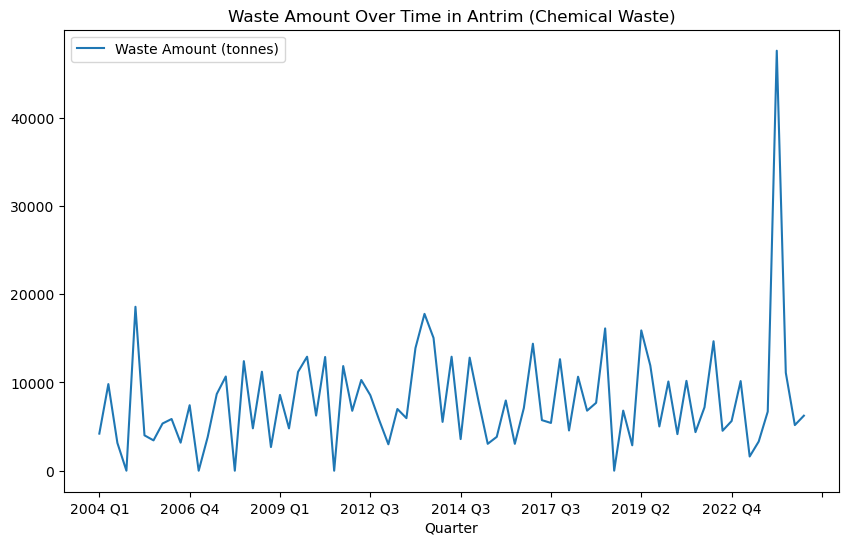

In [ ]:
# Filter data for 'County' == "Antrim" and 'Waste Category' == "chemical waste"
filtered_data = combined_waste_data_3.query('County == "Antrim" and `Waste Category` == "chemical waste"')

# Plot the data
filtered_data.plot(x="Quarter", y="Waste Amount (tonnes)", kind="line", figsize=(10, 6), title="Waste Amount Over Time in Antrim (Chemical Waste)")


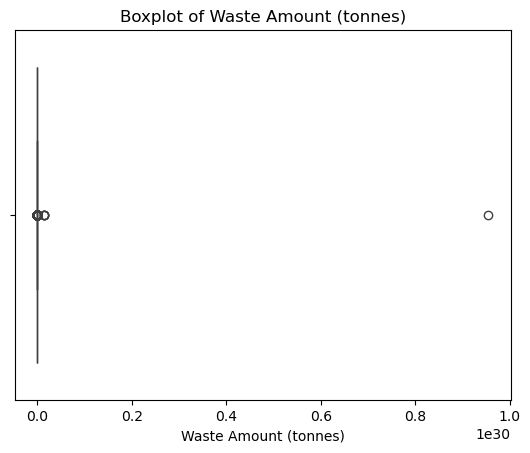

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x = combined_waste_data_3["Waste Amount (tonnes)"])
plt.title("Boxplot of Waste Amount (tonnes)")
plt.show()



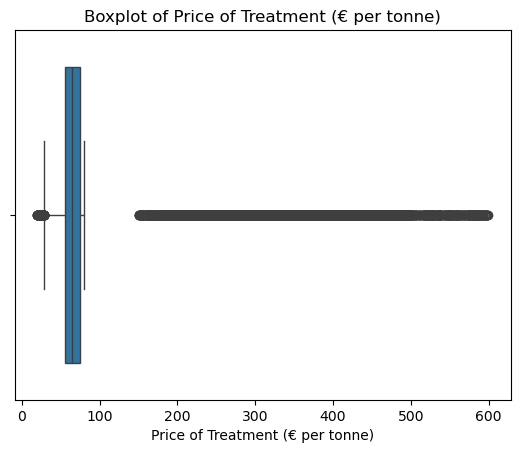

In [ ]:

sns.boxplot(x = combined_waste_data_3["Price of Treatment (€ per tonne)"])
plt.title("Boxplot of Price of Treatment (€ per tonne)")
plt.show()

In [ ]:
Q1 = combined_waste_data_3["Waste Amount (tonnes)"].quantile(0.25)
Q3 = combined_waste_data_3["Waste Amount (tonnes)"].quantile(0.75)

IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = combined_waste_data_3[(combined_waste_data_3["Waste Amount (tonnes)"] < lower) | (combined_waste_data_3["Waste Amount (tonnes)"] > upper)]




In [ ]:
combined_waste_data_3 = combined_waste_data_3[(combined_waste_data_3["Waste Amount (tonnes)"] >= lower) & (combined_waste_data_3["Waste Amount (tonnes)"] <= upper)]



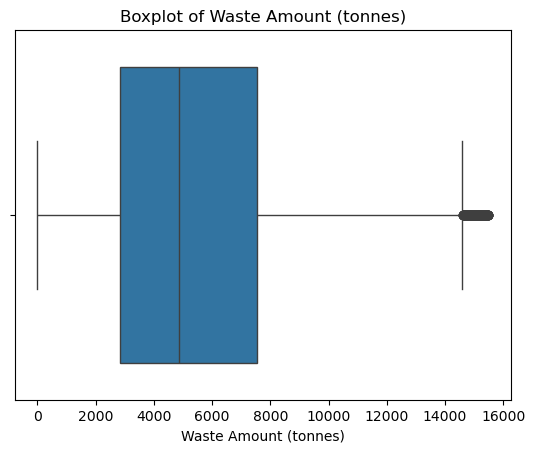

In [ ]:
sns.boxplot(x = combined_waste_data_3["Waste Amount (tonnes)"])
plt.title("Boxplot of Waste Amount (tonnes)")
plt.show()


In [ ]:
Q1 = combined_waste_data_3["Price of Treatment (€ per tonne)"].quantile(0.25)
Q3 = combined_waste_data_3["Price of Treatment (€ per tonne)"].quantile(0.75)

IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = combined_waste_data_3[(combined_waste_data_3["Price of Treatment (€ per tonne)"] < lower) | (combined_waste_data_3["Price of Treatment (€ per tonne)"] > upper)]




In [ ]:
combined_waste_data_3 = combined_waste_data_3[(combined_waste_data_3["Price of Treatment (€ per tonne)"] >= lower) & (combined_waste_data_3["Price of Treatment (€ per tonne)"] <= upper)]


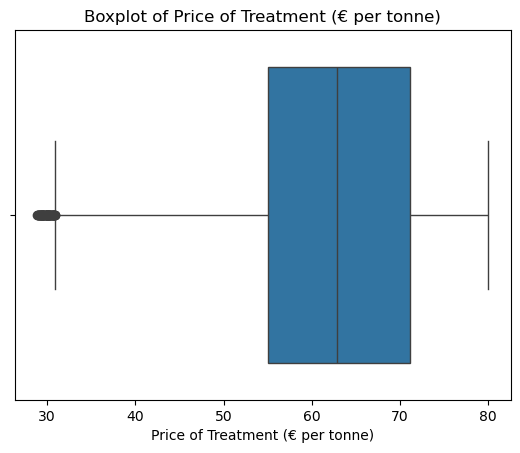

In [ ]:

sns.boxplot(x = combined_waste_data_3["Price of Treatment (€ per tonne)"])
plt.title("Boxplot of Price of Treatment (€ per tonne)")
plt.show()

In [ ]:
combined_waste_data_3.to_pickle("combine_waste_data_4.pk1")

In [ ]:
import pandas as pd
combined_waste_data_4 = pd.read_pickle("combine_waste_data_4.pk1")

In [ ]:
combined_waste_data_4.info()

<class 'pandas.core.frame.DataFrame'>
Index: 17969 entries, 23 to 37129
Data columns (total 7 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Quarter                           17969 non-null  object 
 1   County                            17969 non-null  object 
 2   Waste Type                        17969 non-null  object 
 3   Waste Category                    17969 non-null  object 
 4   Waste Amount (tonnes)             17969 non-null  float64
 5   Treatment Method                  17969 non-null  object 
 6   Price of Treatment (€ per tonne)  17969 non-null  float64
dtypes: float64(2), object(5)
memory usage: 1.1+ MB


In [ ]:
combined_waste_data_4.describe().T

,count,mean,std,min,25%,50%,75%,max
Waste Amount (tonnes),17969.0,5311.481496,3520.792683,1.0,2861.96,4842.49,7385.96,15483.0
Price of Treatment (€ per tonne),17969.0,62.576571,10.587891,28.9,55.02,62.89,71.09,80.0


In [ ]:
combined_waste_data_4

,Quarter,County,Waste Type,Waste Category,Waste Amount (tonnes),Treatment Method,Price of Treatment (€ per tonne)
23,2004 Q1,Antrim,Hazardous,electronic waste (e-waste),14926.92,Recovery - Recycling,69.00
25,2004 Q1,Antrim,Hazardous,industrial hazardous waste,8052.58,Disposal - Other,69.79
28,2004 Q1,Antrim,Non-Hazardous,agricultural waste,4311.98,Recovery - Composting,66.70
29,2004 Q1,Antrim,Non-Hazardous,construction and demolition waste,4359.11,Disposal - Landfill,36.00
30,2004 Q1,Antrim,Non-Hazardous,construction and demolition waste,9461.78,Recovery - Recycling,60.58
...,...,...,...,...,...,...,...
37125,2024 Q4,Wicklow,Non-Hazardous,industrial non-hazardous waste,5881.82,Disposal - Landfill,50.04
37126,2024 Q4,Wicklow,Non-Hazardous,municipal solid waste,9.00,Disposal - Landfill,66.16
37127,2024 Q4,Wicklow,Non-Hazardous,municipal solid waste,3916.67,Recovery - Energy Recovery,66.67
37128,2024 Q4,Wicklow,Non-Hazardous,municipal solid waste,4661.86,Recovery - Energy Recovery,70.32


In [ ]:
# Total waste by county
total_waste_by_county = combined_waste_data_4.groupby("County")["Waste Amount (tonnes)"].sum()
print(total_waste_by_county)


County
Antrim       3.889643e+06
Carlow       3.661940e+06
Cavan        3.678182e+06
Clare        3.700551e+06
Cork         3.424382e+06
Donegal      3.529761e+06
Down         3.651808e+06
Dublin       3.582195e+06
Galway       3.657822e+06
Kerry        4.016897e+06
Kildare      3.614488e+06
Kilkenny     3.805020e+06
Laois        3.710677e+06
Limerick     3.659403e+06
Louth        3.850869e+06
Mayo         3.500355e+06
Meath        3.829387e+06
Monaghan     3.616618e+06
Offaly       3.890912e+06
Roscommon    3.538092e+06
Sligo        3.511754e+06
Tipperary    3.704395e+06
Waterford    3.623874e+06
Westmeath    3.484898e+06
Wexford      3.668843e+06
Wicklow      3.639244e+06
Name: Waste Amount (tonnes), dtype: float64


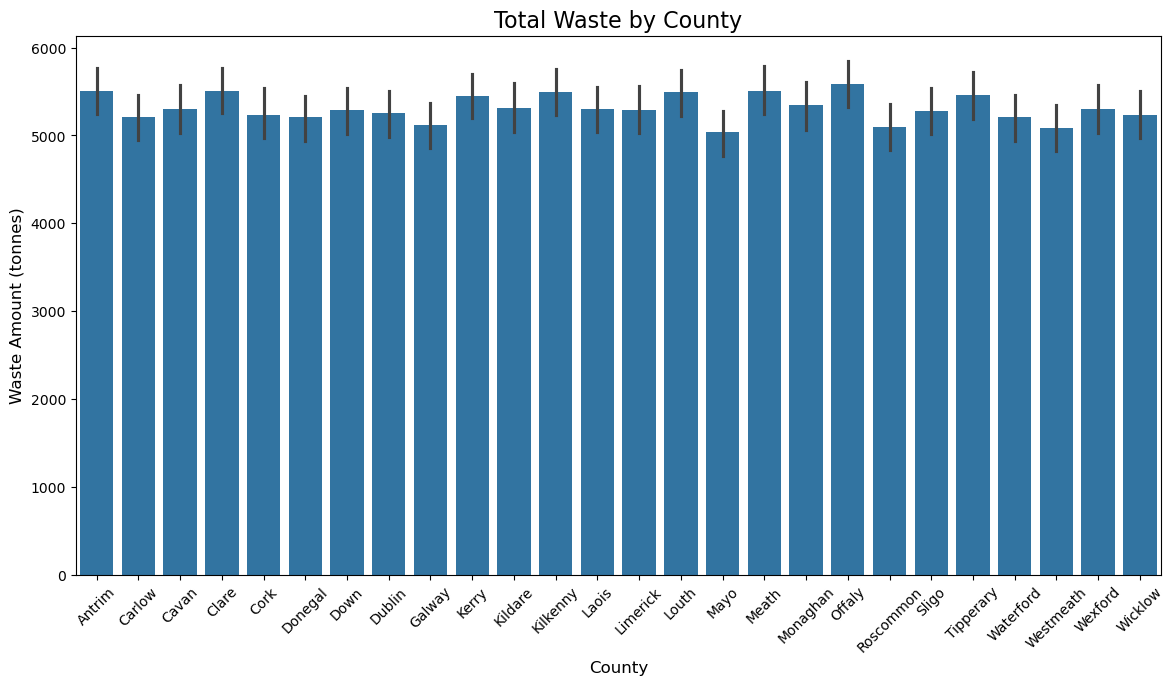

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 7))
sns.barplot(data = combined_waste_data_4, x='County', y='Waste Amount (tonnes)')

plt.title("Total Waste by County", fontsize=16)
plt.xlabel("County", fontsize=12)
plt.ylabel("Waste Amount (tonnes)", fontsize=12)
plt.xticks(rotation=45)  # Rotate x-axis labels for readability
plt.show()


In [ ]:
# Calculate Cost of Waste Treatment

combined_waste_data_4["Cost of Treatment (k)"] = ((combined_waste_data_4["Waste Amount (tonnes)"] * combined_waste_data_4["Price of Treatment (€ per tonne)"])/1000).round(2)



In [ ]:
combined_waste_data_4

,Quarter,County,Waste Type,Waste Category,Waste Amount (tonnes),Treatment Method,Price of Treatment (€ per tonne),Cost of Treatment (k)
23,2004 Q1,Antrim,Hazardous,electronic waste (e-waste),14926.92,Recovery - Recycling,69.00,1029.96
25,2004 Q1,Antrim,Hazardous,industrial hazardous waste,8052.58,Disposal - Other,69.79,561.99
28,2004 Q1,Antrim,Non-Hazardous,agricultural waste,4311.98,Recovery - Composting,66.70,287.61
29,2004 Q1,Antrim,Non-Hazardous,construction and demolition waste,4359.11,Disposal - Landfill,36.00,156.93
30,2004 Q1,Antrim,Non-Hazardous,construction and demolition waste,9461.78,Recovery - Recycling,60.58,573.19
...,...,...,...,...,...,...,...,...
37125,2024 Q4,Wicklow,Non-Hazardous,industrial non-hazardous waste,5881.82,Disposal - Landfill,50.04,294.33
37126,2024 Q4,Wicklow,Non-Hazardous,municipal solid waste,9.00,Disposal - Landfill,66.16,0.60
37127,2024 Q4,Wicklow,Non-Hazardous,municipal solid waste,3916.67,Recovery - Energy Recovery,66.67,261.12
37128,2024 Q4,Wicklow,Non-Hazardous,municipal solid waste,4661.86,Recovery - Energy Recovery,70.32,327.82


In [ ]:
# cost of treatment by waste category
cost_of_treatment_by_waste_category = combined_waste_data_4.groupby("Waste Category")["Cost of Treatment (k)"].sum()
print(cost_of_treatment_by_waste_category)



Waste Category
agricultural waste                   806921.32
chemical waste                       563688.89
construction and demolition waste    661601.72
electronic waste (e-waste)           375648.73
industrial hazardous waste           630351.62
industrial non-hazardous waste       841821.11
medical waste                        440085.15
municipal solid waste                899401.60
organic waste                        751527.90
Name: Cost of Treatment (k), dtype: float64


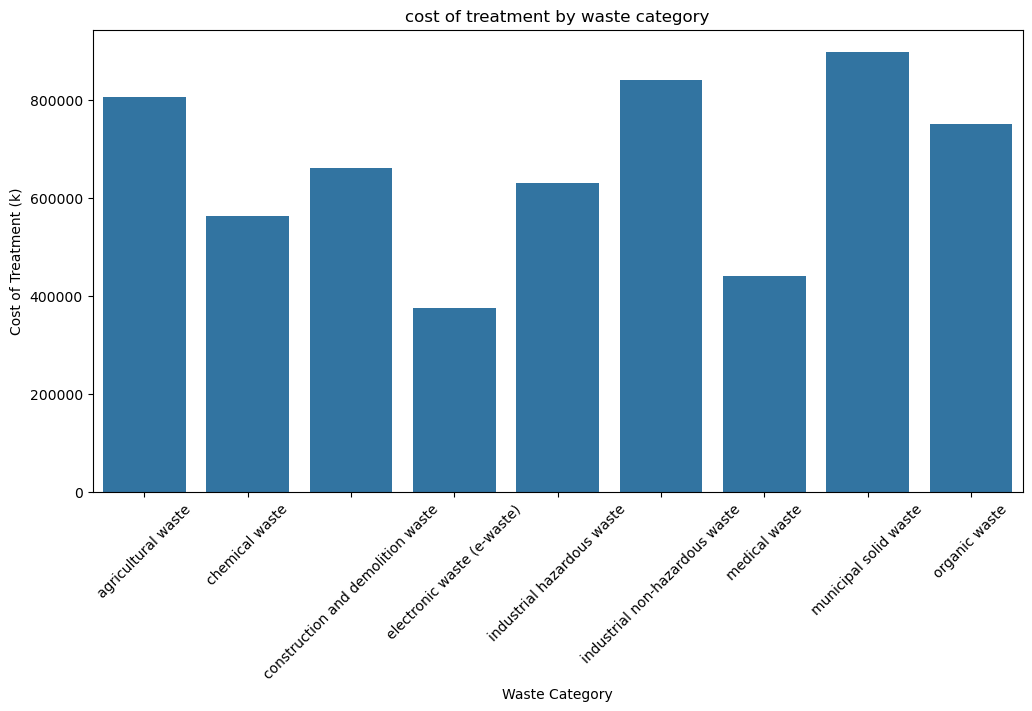

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

cost_of_treatment_by_waste_category_dataframe = cost_of_treatment_by_waste_category.reset_index()


plt.figure(figsize =(12,6))
sns.barplot(data = cost_of_treatment_by_waste_category_dataframe, x = "Waste Category", y = "Cost of Treatment (k)")

plt.title("cost of treatment by waste category")
plt.xlabel("Waste Category")
plt.ylabel("Cost of Treatment (k)")
plt.xticks(rotation = 45)
plt.show()



In [ ]:
combined_waste_data_4.to_pickle("combine_waste_data_5.pk1")

In [ ]:
import pandas as pd
combined_waste_data_5 = pd.read_pickle("combine_waste_data_5.pk1")

In [ ]:
combined_waste_data_5

,Quarter,County,Waste Type,Waste Category,Waste Amount (tonnes),Treatment Method,Price of Treatment (€ per tonne),Cost of Treatment (k)
23,2004 Q1,Antrim,Hazardous,electronic waste (e-waste),14926.92,Recovery - Recycling,69.00,1029.96
25,2004 Q1,Antrim,Hazardous,industrial hazardous waste,8052.58,Disposal - Other,69.79,561.99
28,2004 Q1,Antrim,Non-Hazardous,agricultural waste,4311.98,Recovery - Composting,66.70,287.61
29,2004 Q1,Antrim,Non-Hazardous,construction and demolition waste,4359.11,Disposal - Landfill,36.00,156.93
30,2004 Q1,Antrim,Non-Hazardous,construction and demolition waste,9461.78,Recovery - Recycling,60.58,573.19
...,...,...,...,...,...,...,...,...
37125,2024 Q4,Wicklow,Non-Hazardous,industrial non-hazardous waste,5881.82,Disposal - Landfill,50.04,294.33
37126,2024 Q4,Wicklow,Non-Hazardous,municipal solid waste,9.00,Disposal - Landfill,66.16,0.60
37127,2024 Q4,Wicklow,Non-Hazardous,municipal solid waste,3916.67,Recovery - Energy Recovery,66.67,261.12
37128,2024 Q4,Wicklow,Non-Hazardous,municipal solid waste,4661.86,Recovery - Energy Recovery,70.32,327.82


In [ ]:

# Treatment Efficiency (€ per tonne)

combined_waste_data_5["Treatment Efficiency (€ per tonne)"] = combined_waste_data_5["Cost of Treatment (k)"] * 1000 / combined_waste_data_5["Waste Amount (tonnes)"]


In [ ]:
combined_waste_data_5

,Quarter,County,Waste Type,Waste Category,Waste Amount (tonnes),Treatment Method,Price of Treatment (€ per tonne),Cost of Treatment (k),Treatment Efficiency (€ per tonne)
23,2004 Q1,Antrim,Hazardous,electronic waste (e-waste),14926.92,Recovery - Recycling,69.00,1029.96,69.000169
25,2004 Q1,Antrim,Hazardous,industrial hazardous waste,8052.58,Disposal - Other,69.79,561.99,69.790055
28,2004 Q1,Antrim,Non-Hazardous,agricultural waste,4311.98,Recovery - Composting,66.70,287.61,66.700217
29,2004 Q1,Antrim,Non-Hazardous,construction and demolition waste,4359.11,Disposal - Landfill,36.00,156.93,36.000468
30,2004 Q1,Antrim,Non-Hazardous,construction and demolition waste,9461.78,Recovery - Recycling,60.58,573.19,60.579510
...,...,...,...,...,...,...,...,...,...
37125,2024 Q4,Wicklow,Non-Hazardous,industrial non-hazardous waste,5881.82,Disposal - Landfill,50.04,294.33,50.040634
37126,2024 Q4,Wicklow,Non-Hazardous,municipal solid waste,9.00,Disposal - Landfill,66.16,0.60,66.666667
37127,2024 Q4,Wicklow,Non-Hazardous,municipal solid waste,3916.67,Recovery - Energy Recovery,66.67,261.12,66.668879
37128,2024 Q4,Wicklow,Non-Hazardous,municipal solid waste,4661.86,Recovery - Energy Recovery,70.32,327.82,70.319572


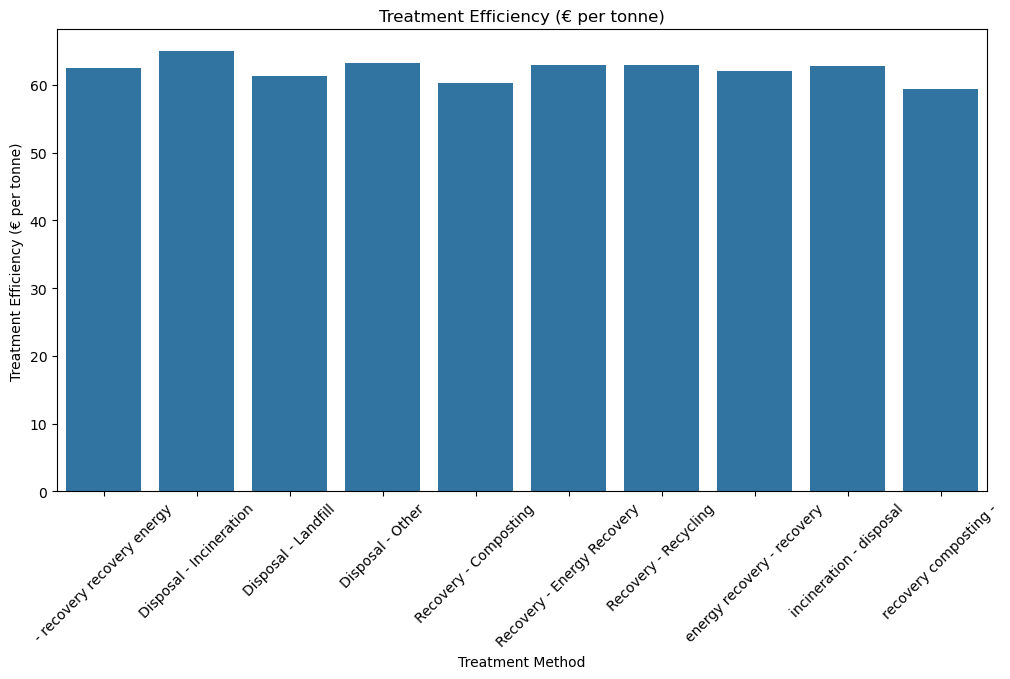

In [ ]:
efficiency_by_treatment_method = combined_waste_data_5.groupby("Treatment Method")["Treatment Efficiency (€ per tonne)"].mean().reset_index()

plt.figure(figsize=(12,6))
sns.barplot(data = efficiency_by_treatment_method, x = "Treatment Method", y = "Treatment Efficiency (€ per tonne)" )

plt.title("Treatment Efficiency (€ per tonne)")
plt.xlabel("Treatment Method")
plt.ylabel("Treatment Efficiency (€ per tonne)")
plt.xticks(rotation = 45)
plt.show()


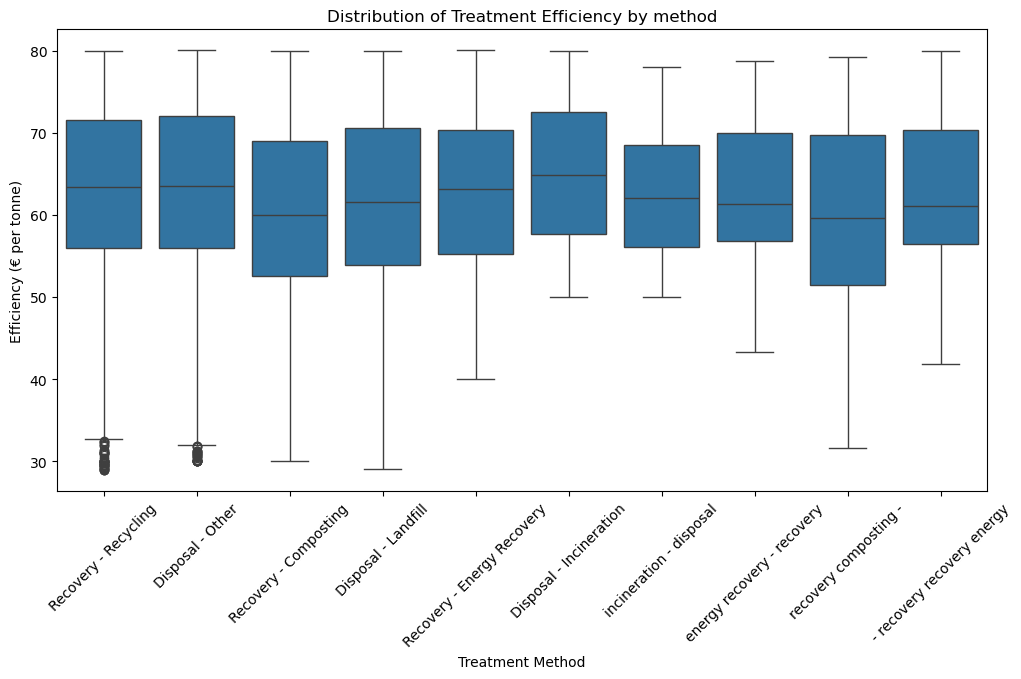

In [ ]:
plt.figure(figsize = (12,6))
sns.boxplot(data = combined_waste_data_5, x = "Treatment Method", y = "Treatment Efficiency (€ per tonne)")

plt.title("Distribution of Treatment Efficiency by method")
plt.xlabel("Treatment Method")
plt.ylabel("Efficiency (€ per tonne)")
plt.xticks(rotation = 45)
plt.show()




In [ ]:
combined_waste_data_5

,Quarter,County,Waste Type,Waste Category,Waste Amount (tonnes),Treatment Method,Price of Treatment (€ per tonne),Cost of Treatment (k),Treatment Efficiency (€ per tonne)
23,2004 Q1,Antrim,Hazardous,electronic waste (e-waste),14926.92,Recovery - Recycling,69.00,1029.96,69.000169
25,2004 Q1,Antrim,Hazardous,industrial hazardous waste,8052.58,Disposal - Other,69.79,561.99,69.790055
28,2004 Q1,Antrim,Non-Hazardous,agricultural waste,4311.98,Recovery - Composting,66.70,287.61,66.700217
29,2004 Q1,Antrim,Non-Hazardous,construction and demolition waste,4359.11,Disposal - Landfill,36.00,156.93,36.000468
30,2004 Q1,Antrim,Non-Hazardous,construction and demolition waste,9461.78,Recovery - Recycling,60.58,573.19,60.579510
...,...,...,...,...,...,...,...,...,...
37125,2024 Q4,Wicklow,Non-Hazardous,industrial non-hazardous waste,5881.82,Disposal - Landfill,50.04,294.33,50.040634
37126,2024 Q4,Wicklow,Non-Hazardous,municipal solid waste,9.00,Disposal - Landfill,66.16,0.60,66.666667
37127,2024 Q4,Wicklow,Non-Hazardous,municipal solid waste,3916.67,Recovery - Energy Recovery,66.67,261.12,66.668879
37128,2024 Q4,Wicklow,Non-Hazardous,municipal solid waste,4661.86,Recovery - Energy Recovery,70.32,327.82,70.319572


This code determines the overall Cost of Treatment (k) for each category by grouping the data in combined_waste_data_5 by Waste Category.

insight: A pie chart representing the percentage of treatment expenses attributed to each waste category is created from the obtained totals. This aids in determining which waste types require the highest treatment costs as well as how much each affects total expenses.

<Axes: ylabel='Cost of Treatment (k)'>

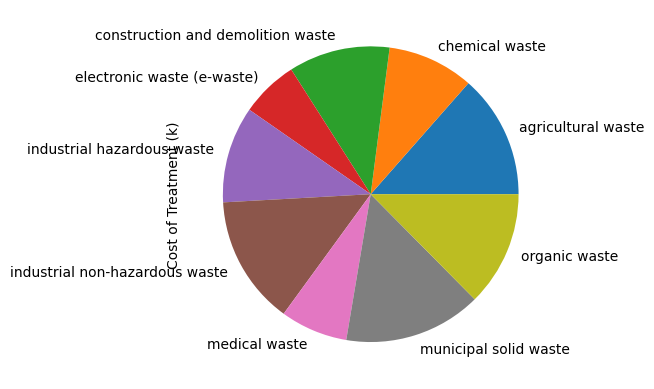

In [ ]:
combined_waste_data_5.groupby("Waste Category")["Cost of Treatment (k)"].sum().plot.pie()

In [ ]:
Saving the data

In [ ]:
combined_waste_data_5.to_pickle("combine_waste_data_6.pk1")

In [ ]:
combined_waste_data_6 = pd.read_pickle("combine_waste_data_6.pk1")

In [ ]:
combined_waste_data_6

,Quarter,County,Waste Type,Waste Category,Waste Amount (tonnes),Treatment Method,Price of Treatment (€ per tonne),Cost of Treatment (k),Treatment Efficiency (€ per tonne)
23,2004 Q1,Antrim,Hazardous,electronic waste (e-waste),14926.92,Recovery - Recycling,69.00,1029.96,69.000169
25,2004 Q1,Antrim,Hazardous,industrial hazardous waste,8052.58,Disposal - Other,69.79,561.99,69.790055
28,2004 Q1,Antrim,Non-Hazardous,agricultural waste,4311.98,Recovery - Composting,66.70,287.61,66.700217
29,2004 Q1,Antrim,Non-Hazardous,construction and demolition waste,4359.11,Disposal - Landfill,36.00,156.93,36.000468
30,2004 Q1,Antrim,Non-Hazardous,construction and demolition waste,9461.78,Recovery - Recycling,60.58,573.19,60.579510
...,...,...,...,...,...,...,...,...,...
37125,2024 Q4,Wicklow,Non-Hazardous,industrial non-hazardous waste,5881.82,Disposal - Landfill,50.04,294.33,50.040634
37126,2024 Q4,Wicklow,Non-Hazardous,municipal solid waste,9.00,Disposal - Landfill,66.16,0.60,66.666667
37127,2024 Q4,Wicklow,Non-Hazardous,municipal solid waste,3916.67,Recovery - Energy Recovery,66.67,261.12,66.668879
37128,2024 Q4,Wicklow,Non-Hazardous,municipal solid waste,4661.86,Recovery - Energy Recovery,70.32,327.82,70.319572
